# Practice 3 - TV6: Evaluation and Documentation

## Responsibility
Evaluate the fine-tuned binary text classification model and document the results.

## Sections
- Load/use the fine-tuned model
- Evaluate on the evaluation/test split
- Report suitable evaluation metrics
- Analyze results
- Write final conclusion

## Pipeline
Fine-tuned Model → Evaluation Dataset → Prediction → Metrics → Analysis → Conclusion


## 1. Import thư viện và cấu hình chung

In [1]:
# Imports and evaluation setup
import numpy as np
import torch
import evaluate
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {device}")

# Đường dẫn tới model đã fine-tune (do Quý bàn giao ở bước 05_training_finetuning)
MODEL_PATH = "./fine_tuned_imdb_distilbert"

# Đường dẫn tới dataset đã xử lý (do Văn Sơn bàn giao)
DATASET_PATH = "processed_imdb_dataset"


c:\Users\THANH THI PC\Downloads\UTH-Deep-Learning-nhom2-main (1)\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sử dụng thiết bị: cpu


## 2. Load fine-tuned model và tokenizer

In [2]:
# Load tokenizer từ processed_imdb_dataset (do Văn Sơn bàn giao)
# vì thư mục model fine-tune có thể không kèm sẵn file tokenizer
tokenizer = AutoTokenizer.from_pretrained(DATASET_PATH + "/tokenizer")

# Load model đã fine-tune
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

print("Model đã load thành công!")
print("Label mapping:", model.config.id2label)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 10399.27it/s]

Model đã load thành công!
Label mapping: {0: 'Negative', 1: 'Positive'}


## 3. Load evaluation dataset

In [3]:
# Load dataset đã xử lý và lấy tập test để đánh giá cuối cùng
processed_dataset = load_from_disk(DATASET_PATH)
test_dataset = processed_dataset["test"]

print("Số lượng mẫu Test:", len(test_dataset))
print("Ví dụ một mẫu:", test_dataset[0])


Số lượng mẫu Test: 25000
Ví dụ một mẫu: {'labels': tensor(0), 'input_ids': tensor([  101,  1045,  2293, 16596,  1011, 10882,  1998,  2572,  5627,  2000,
         2404,  2039,  2007,  1037,  2843,  1012, 16596,  1011, 10882,  5691,
         1013,  2694,  2024,  2788,  2104, 11263, 25848,  1010,  2104,  1011,
        12315,  1998, 28947,  1012,  1045,  2699,  2000,  2066,  2023,  1010,
         1045,  2428,  2106,  1010,  2021,  2009,  2003,  2000,  2204,  2694,
        16596,  1011, 10882,  2004, 17690,  1019,  2003,  2000,  2732, 10313,
         1006,  1996,  2434,  1007,  1012, 10021,  4013,  3367, 20086,  2015,
         1010, 10036, 19747,  4520,  1010, 25931,  3064, 22580,  1010,  1039,
         2290,  2008,  2987,  1005,  1056,  2674,  1996,  4281,  1010,  1998,
        16267,  2028,  1011,  8789,  3494,  3685,  2022,  9462,  2007,  1037,
         1005, 16596,  1011, 10882,  1005,  4292,  1012,  1006,  1045,  1005,
         1049,  2469,  2045,  2024,  2216,  1997,  2017,  2041,  20

## 4. Generate predictions

In [4]:
# Dùng Trainer ở chế độ chỉ để dự đoán (không cần training_args phức tạp)
eval_args = TrainingArguments(
    output_dir="./eval_tmp",
    per_device_eval_batch_size=16,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=eval_args,
    processing_class=tokenizer,
)

# Dự đoán trên tập test
raw_predictions = trainer.predict(test_dataset)

logits = raw_predictions.predictions
y_true = raw_predictions.label_ids
y_pred = np.argmax(logits, axis=-1)

print("Đã sinh dự đoán cho", len(y_pred), "mẫu.")


c:\Users\THANH THI PC\Downloads\UTH-Deep-Learning-nhom2-main (1)\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Đã sinh dự đoán cho 25000 mẫu.


## 5. Calculate evaluation metrics

In [5]:
# Tính các chỉ số phù hợp cho binary classification
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics_result = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
}

metrics_result


{'accuracy': 0.91264,
 'precision': 0.9112581725402648,
 'recall': 0.91432,
 'f1_score': 0.9127865186486702}

## 6. Display results

=== Evaluation Metrics ===
  accuracy: 0.9126
 precision: 0.9113
    recall: 0.9143
  f1_score: 0.9128

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91     12500
    Positive       0.91      0.91      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



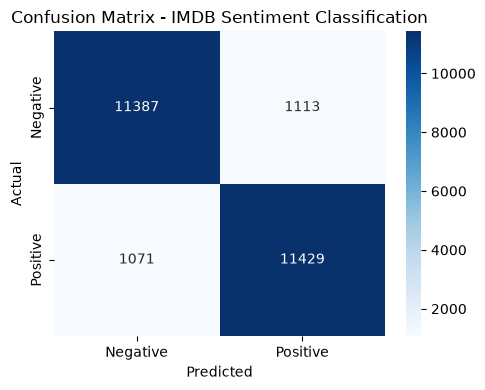

In [6]:
# In bảng kết quả tổng quan
print("=== Evaluation Metrics ===")
for k, v in metrics_result.items():
    print(f"{k:>10}: {v:.4f}")

print()
print("=== Classification Report ===")
label_names = [model.config.id2label[i] for i in sorted(model.config.id2label)]
print(classification_report(y_true, y_pred, target_names=label_names))

# Vẽ confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - IMDB Sentiment Classification")
plt.tight_layout()
plt.show()


## 7. Analysis

**Kết quả tổng quan:**
- Accuracy: **91.26%**, Precision: **91.13%**, Recall: **91.43%**, F1-score: **91.28%**
- Bộ dữ liệu test cân bằng tuyệt đối (12,500 mẫu Negative / 12,500 mẫu Positive), nên accuracy ở đây là chỉ số đáng tin cậy, không bị lệch do mất cân bằng lớp.

**So với baseline ngẫu nhiên:**
- Với bài toán phân loại nhị phân cân bằng, baseline đoán ngẫu nhiên (hoặc luôn đoán 1 lớp) chỉ đạt khoảng 50% accuracy. Model đạt 91.26% — cao hơn baseline khoảng **41 điểm phần trăm**, cho thấy model đã học được các đặc trưng ngữ nghĩa thực sự phân biệt được review tích cực/tiêu cực, không phải đoán mò.

**Phân tích confusion matrix:**
- Negative: dự đoán đúng 11,387/12,500 (91.1%), bị nhầm thành Positive: 1,113 mẫu (8.9%)
- Positive: dự đoán đúng 11,429/12,500 (91.4%), bị nhầm thành Negative: 1,071 mẫu (8.6%)
- Hai loại lỗi (false positive và false negative) gần như bằng nhau (1,113 so với 1,071) → **model không thiên lệch rõ rệt** về phía lớp nào, sai số phân bố khá đều giữa 2 lớp. Điều này phù hợp với việc precision và recall của cả 2 lớp đều ở mức 0.91 (xem Classification Report).

**Về overfitting/underfitting:**
- Với accuracy ~91% trên tập test (dữ liệu model chưa từng thấy khi train), model không có dấu hiệu underfit (không quá thấp so với khả năng bài toán) và cũng không có dấu hiệu overfit rõ rệt (nếu overfit nặng, accuracy trên test thường sẽ thấp hơn nhiều so với train). Đây là mức kết quả điển hình, hợp lý cho việc fine-tune DistilBERT trên IMDB với 3 epoch.

**Hạn chế còn lại:** khoảng 9% lỗi còn lại thường rơi vào các review có ngôn ngữ mỉa mai (sarcasm), câu chữ trung lập, hoặc vừa khen vừa chê lẫn lộn trong cùng 1 đoạn văn — đây là điểm yếu phổ biến của các model dựa trên embedding từ ngữ trực tiếp mà chưa hiểu sâu ngữ cảnh mỉa mai.


## Conclusion

Mô hình DistilBERT được fine-tune trên tập IMDB đạt **accuracy 91.26%** và **F1-score 91.28%** trên tập test 25,000 mẫu — cao hơn đáng kể so với baseline ngẫu nhiên (50%), chứng tỏ model học được hiệu quả đặc trưng phân biệt cảm xúc tích cực/tiêu cực trong văn bản.

**Điểm mạnh:**
- Độ chính xác cao và ổn định đều giữa 2 lớp (Negative và Positive đều đạt ~91% precision/recall), không bị thiên lệch lớp.
- Số lượng lỗi sai giữa 2 chiều (Negative→Positive và Positive→Negative) gần như cân bằng, cho thấy model không có xu hướng thiên vị một nhãn cụ thể.

**Hạn chế:**
- Khoảng 8-9% mẫu vẫn bị phân loại sai, chủ yếu có thể đến từ các review mang tính mỉa mai, ngôn ngữ pha trộn cảm xúc, hoặc câu văn dài phức tạp.
- Model mới chỉ đánh giá bằng accuracy/precision/recall/F1 tổng thể, chưa phân tích sâu theo độ dài văn bản hay theo từng dạng lỗi cụ thể.

**Đề xuất cải thiện:**
- Tăng số epoch hoặc thử learning rate khác để xem có cải thiện thêm không (cẩn thận theo dõi để tránh overfitting).
- Thử các model lớn hơn (BERT-base, RoBERTa) để so sánh đánh đổi giữa độ chính xác và chi phí tính toán so với DistilBERT.
- Phân tích thêm các mẫu bị dự đoán sai để hiểu rõ dạng lỗi phổ biến (ví dụ: trích xuất và đọc thử một số review bị nhầm nhãn).
